# 박스좌표와IoU

검출 박스의 좌표 표현을 양방향으로 변환하고 겹침 정도를 직접 계산합니다.

함수명·입출력·API 예시는 제공합니다. **작성 구간의 처리 로직을 직접 구성하세요.**
검증 셀은 수정하지 않습니다. 파일 안에서는 위에서부터 실행합니다.


In [2]:
# 00_오후 실습 준비 실행 이후 코드 실행할것. 

from pathlib import Path
import os, sys, json, time
# ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'speed_project.py').exists()), None)
# if ROOT is None: raise RuntimeError('오후_최종본 폴더에서 실행하세요.')

ROOT = Path(r"C:\Users\User\.ngv_day4_2026\pm\1b2d65c48c7e")

sys.path.insert(0,str(ROOT))
os.environ['MPLCONFIGDIR']=str(ROOT/'.runtime/matplotlib')
os.environ['YOLO_CONFIG_DIR']=str(ROOT/'.runtime/yolo')
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageOps, ImageDraw
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
torch.set_num_threads(4)
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False
from ultralytics import YOLO
dataset=ROOT/'dataset_group20_seed42'
if not (dataset/'annotations.json').exists():
    from speed_project import prepare_data
    dataset,_=prepare_data(seed=42)
records=json.loads((dataset/'annotations.json').read_text(encoding='utf-8'))
run=ROOT/'runs/verified'
WEIGHTS=run/'weights/best.pt'


## 실제 사진과 정답 박스 · 제공 코드


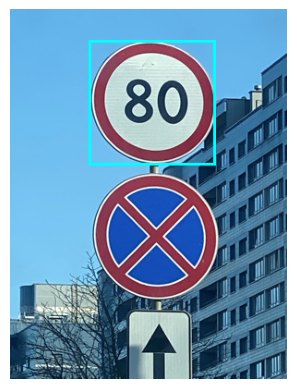

사진 W,H: 300 400 박스: [85.0, 33.0, 222.0, 168.0]


In [3]:
sample=next(r for r in records.values() if r['split']=='val' and r['boxes'])
image=Image.open(dataset/'images/val'/sample['image']).convert('RGB');W,H=image.size
overlay=image.copy();ImageDraw.Draw(overlay).rectangle(sample['boxes'][0],outline='cyan',width=3)
plt.imshow(overlay);plt.axis('off');plt.show();print('사진 W,H:',W,H,'박스:',sample['boxes'][0])


## ✏️ B01 · 박스 좌표 변환기 구현

두 함수를 구현합니다. 픽셀 좌표 `[x1,y1,x2,y2]`와 YOLO의 정규화된 `[중심x,중심y,너비,높이]`를 변환하세요.
가로 성분은 W, 세로 성분은 H를 기준으로 합니다. 중간 계산에서 정수로 바꾸지 않습니다.

### 사용할 수 있는 API
리스트 분해: `a,b,c,d=values`. 반환: `[값1,값2,값3,값4]`.
중심은 양 끝의 평균, 길이는 끝−시작입니다. 복원은 중심에서 길이의 절반만큼 양쪽으로 이동합니다.


In [ ]:
# ===== 실습 B01 시작 =====

def to_yolo(box, W, H):
    x1, y1, x2, y2 = box
    return [(x1 + x2) / (2 * W), (y1 + y2) / (2 * H), (x2 - x1) / W, (y2 - y1) / H]

def to_pixels(box, W, H):
    # box = [x_center, y_center, w_norm, h_norm]
    x_center, y_center, w_norm, h_norm = box
    
    # 정규화된 좌표를 픽셀 단위 크기로 복원
    cx = x_center * W
    cy = y_center * H
    w = w_norm * W
    h = h_norm * H
    
    # 중심 좌표(cx, cy)와 크기(w, h)로부터 원래의 x1, y1, x2, y2 계산
    x1 = cx - w / 2
    y1 = cy - h / 2
    x2 = cx + w / 2
    y2 = cy + h / 2
    
    return [x1, y1, x2, y2]

# ===== 실습 B01 끝 =====
# 역함수


**B01 검증** · 아래 셀이 통과한 뒤 실제 데이터에 적용합니다.


In [10]:
assert np.allclose(to_yolo([10,20,50,80],100,200),[.3,.25,.4,.3]),'B01: 가로·세로 정규화 기준을 확인하세요.'
assert np.allclose(to_pixels([.3,.25,.4,.3],100,200),[10,20,50,80])
for box,w,h in [([0,0,320,200],320,200),([5.5,8.2,60.3,170.8],100,200),(sample['boxes'][0],W,H)]:
    assert np.allclose(to_pixels(to_yolo(box,w,h),w,h),box),'B01: 왕복 변환을 확인하세요.'
print('B01 통과: 비정사각형·소수 좌표·왕복')


B01 통과: 비정사각형·소수 좌표·왕복


## ✏️ B02 · IoU 함수 구현

두 xyxy 박스의 교집합 면적/합집합 면적을 반환합니다. 겹치지 않거나 합집합이 0이면 0입니다.
부분 겹침·포함·완전 일치·분리를 같은 함수로 처리하세요.

### 사용할 수 있는 API
`min`, `max`, 사칙연산.
교집합의 한 축 길이: 두 끝 중 작은 값−두 시작 중 큰 값. 음수 길이는 0입니다.
합집합은 두 면적 합에서 교집합을 한 번 뺀 값입니다.


In [11]:
# ===== 실습 B02 시작 =====

def iou(a,b):
    raise NotImplementedError('B02: 교집합과 합집합 계산')

# ===== 실습 B02 끝 =====


**B02 검증** · 아래 셀이 통과한 뒤 실제 데이터에 적용합니다.


In [12]:
a=[0,0,10,10]
for b,expected in [([5,0,15,10],1/3),([2,2,8,8],.36),(a,1),([10,0,20,10],0),([20,20,30,30],0)]:
    assert np.isclose(iou(a,b),expected) and np.isclose(iou(b,a),expected),'B02: 겹침·포함·대칭을 확인하세요.'
assert iou([0,0,0,0],[0,0,0,0])==0
print('B02 통과: 겹침·포함·일치·분리·면적0')


NotImplementedError: B02: 교집합과 합집합 계산

## 실제 박스에서 위치와 크기 비교 · 제공 코드
같은 정답 박스를 기준으로 한 조건씩 바꿉니다.


In [ ]:
gt=sample['boxes'][0];x1,y1,x2,y2=gt;cx,cy=(x1+x2)/2,(y1+y2)/2
fig,axes=plt.subplots(2,3,figsize=(10,7))
for ax,ratio in zip(axes[0],[0,.25,.75]):
    shift=(x2-x1)*ratio;box=[x1+shift,y1,x2+shift,y2]
    im=image.copy();d=ImageDraw.Draw(im);d.rectangle(gt,outline='cyan',width=3);d.rectangle(box,outline='red',width=2)
    ax.imshow(im);ax.set_title(f'너비 {ratio}배 이동 / IoU {iou(gt,box):.3f}');ax.axis('off')
for ax,scale in zip(axes[1],[.5,1.,2.]):
    w,h=(x2-x1)*scale,(y2-y1)*scale;box=[cx-w/2,cy-h/2,cx+w/2,cy+h/2]
    im=image.copy();d=ImageDraw.Draw(im);d.rectangle(gt,outline='cyan',width=3);d.rectangle(box,outline='red',width=2)
    ax.imshow(im);ax.set_title(f'크기 {scale}배 / IoU {iou(gt,box):.3f}');ax.axis('off')
plt.tight_layout();plt.show()
